In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import pandas as pd
import numpy as np
import os

2026-04-19 11:58:54.798998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776599935.019328      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776599935.085861      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776599935.600846      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776599935.600891      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776599935.600894      55 computation_placer.cc:177] computation placer alr

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "/kaggle/input/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/kaggle/input/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


In [4]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        BatchNormalization(),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),

        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])
    return model

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False  # Freeze

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [6]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [7]:
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inputs=base.input, outputs=out)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
def train_model(model, name):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=15,
        callbacks=[early_stop],
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"{name} Best Val Accuracy:", val_acc)

    return model, val_acc

In [11]:
results = {}

cnn_model, acc_cnn = train_model(build_cnn(), "CNN")
results["CNN"] = (cnn_model, acc_cnn)

mobilenet_model, acc_mob = train_model(build_mobilenet(), "MobileNet")
results["MobileNet"] = (mobilenet_model, acc_mob)

resnet_model, acc_res = train_model(build_resnet(), "ResNet")
results["ResNet"] = (resnet_model, acc_res)

efficient_model, acc_eff = train_model(build_efficientnet(), "EfficientNet")
results["EfficientNet"] = (efficient_model, acc_eff)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776600334.644553      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776600334.650627      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can i

Epoch 1/15


I0000 00:00:1776600340.452344     163 service.cc:152] XLA service 0x7b6270002610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776600340.452392     163 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776600340.452398     163 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776600341.013185     163 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-19 12:05:43.291560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 12:05:43.439128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/119 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.4922 - loss: 3.9307 

I0000 00:00:1776600346.742943     163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

 65/119 ━━━━━━━━━━━━━━━━━━━━ 25s 472ms/step - accuracy: 0.5138 - loss: 3.0361

2026-04-19 13:02:19.312243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:02:19.450969: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:02:19.777801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:02:19.919757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:02:20.061962: E external/local_xla/xla/stream_

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.5197 - loss: 2.9858

2026-04-19 13:03:18.995985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:03:19.137073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:03:19.467201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:03:19.609222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 13:03:20.441688: E external/local_xla/xla/stream_

119/119 ━━━━━━━━━━━━━━━━━━━━ 126s 851ms/step - accuracy: 0.5198 - loss: 2.9849 - val_accuracy: 0.4593 - val_loss: 2.6762
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 606ms/step - accuracy: 0.5070 - loss: 2.6381 - val_accuracy: 0.5206 - val_loss: 2.3996
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 597ms/step - accuracy: 0.5138 - loss: 2.3737 - val_accuracy: 0.5291 - val_loss: 2.1781
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 73s 610ms/step - accuracy: 0.5548 - loss: 2.1385 - val_accuracy: 0.5132 - val_loss: 1.9957
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 603ms/step - accuracy: 0.5597 - loss: 1.9652 - val_accuracy: 0.5280 - val_loss: 1.8436
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 598ms/step - accuracy: 0.5295 - loss: 1.8305 - val_accuracy: 0.5323 - val_loss: 1.7161
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 598ms/step - accuracy: 0.5685 - loss: 1.6905 - val_accuracy: 0.5344 - val_loss: 1.6067
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.5641 - loss: 1.5883 - va

In [12]:
best_name = max(results, key=lambda x: results[x][1])
best_model = results[best_name][0]

print("Best Model:", best_name)

Best Model: MobileNet


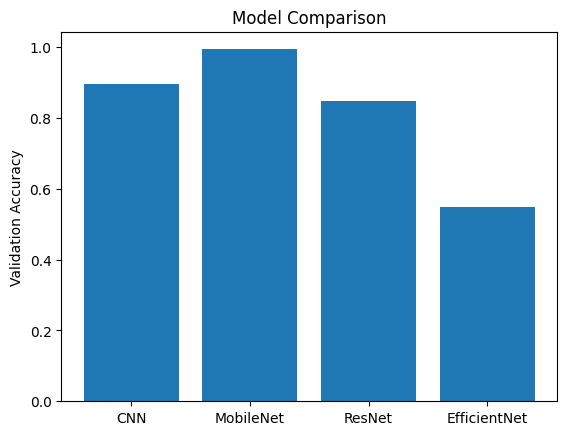

In [16]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = [results[m][1] for m in models]
#Itz Ary99Pk
plt.bar(models, accuracies)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()